In [1]:
from hardware import SLMManager

sim_mode = False
slm_manager = SLMManager(sim_mode=sim_mode)


Validating DPI awareness...success
Loading Blink SDK libraries...success
Initializing SDK...success
Found 1 SLM controller(s)
Loading LUT file...success
✅ SLM connected successfully, resolution: (1152, 1920)


In [ ]:
import config
from optics_utils import process_parameters
from phase_generators import PhaseGenerator
# 默认参数字典 from config
test_raw_params = {}
test_raw_params.update(config.COMMON_DEFAULTS)
test_raw_params.update(config.OPTIMIZED_DEFAULTS)
test_raw_params.update(config.INTERNAL)

# 添加测试需要的基本信息 (这些信息之前GUI提供)
test_raw_params['shape'] = slm_manager.shape
test_raw_params['N'] = 900 # ROI尺寸

# fix
test_raw_params['focal_length_coarse'] = 58.5

# 调用参数处理函数
final_params = process_parameters(test_raw_params)

# Fresnel lens 
Optimizer2 = PhaseGenerator(final_params) 
Optimizer2.generate(mode='fresnel')
phase_8bit = Optimizer2.update_phase_8bit(215)
if not sim_mode:
    slm_manager.upload(phase_8bit)

Using device: cuda
900 7
Phase pattern uploaded to SLM.


Using device: cuda


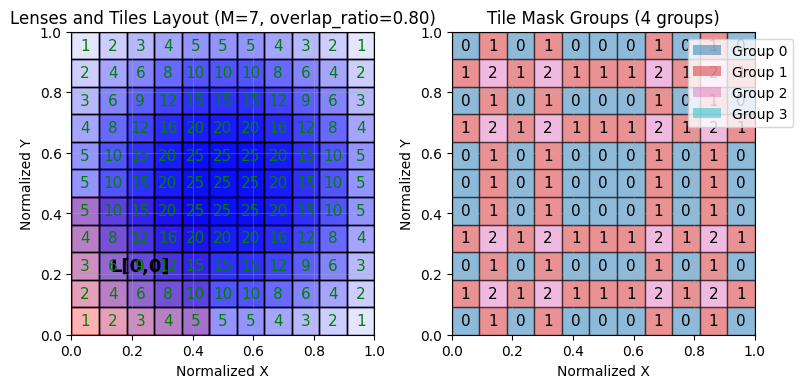


Tile Statistics:
Total tiles: 121
Grid dimensions: 13 x 13
Tiles per group: {0: 49, 1: 56, 2: 16, 3: 0}
Lens contribution distribution: {1: 4, 2: 8, 3: 8, 4: 12, 5: 12, 6: 8, 8: 8, 10: 12, 9: 4, 12: 8, 15: 12, 16: 4, 20: 12, 25: 9}


In [ ]:
# Optimization
final_params['overlap_ratio'] = 0.8
final_params['airy_correction'] = 0.9
final_params['mask_count'] = 4
final_params['interleaving'] = 'coarse2'
Optimizer = PhaseGenerator(final_params) 
Optimizer._prepare_template()


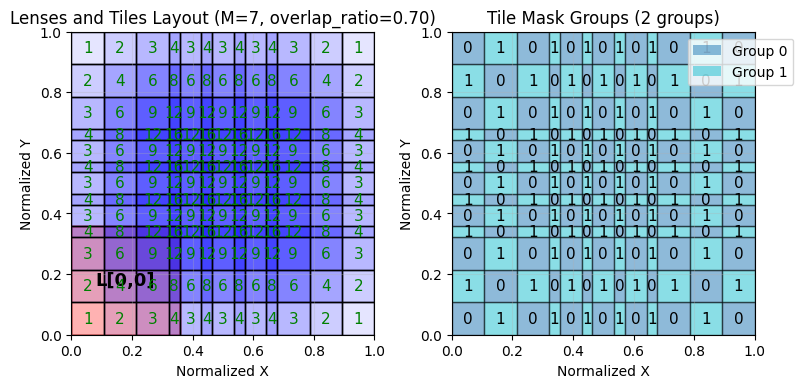


Tile Statistics:
Total tiles: 169
Grid dimensions: 13 x 13
Tiles per group: {0: 85, 1: 84}
Lens contribution distribution: {1: 4, 2: 8, 3: 20, 4: 20, 6: 20, 8: 16, 9: 25, 12: 40, 16: 16}
Starting optimization with 500 iterations...
Iter: 1/500 Focal_mse: 4726.1846 Eff_mean: 0.0014 Eff_std: 0.0004 Masked: 1186.1735 Total: 5.9123e+03
Iter: 51/500 Focal_mse: 560.5609 Eff_mean: 0.6543 Eff_std: 0.0610 Masked: 511.7494 Total: 1.0664e+03
Iter: 101/500 Focal_mse: 386.3178 Eff_mean: 0.7224 Eff_std: 0.0500 Masked: 472.6748 Total: 8.5227e+02
Iter: 151/500 Focal_mse: 371.4500 Eff_mean: 0.7262 Eff_std: 0.0469 Masked: 469.0739 Total: 8.3373e+02
Iter: 201/500 Focal_mse: 363.1243 Eff_mean: 0.7278 Eff_std: 0.0440 Masked: 467.1913 Total: 8.2348e+02
Iter: 251/500 Focal_mse: 357.5853 Eff_mean: 0.7291 Eff_std: 0.0425 Masked: 465.7987 Total: 8.1652e+02
Iter: 301/500 Focal_mse: 354.0575 Eff_mean: 0.7300 Eff_std: 0.0420 Masked: 464.8410 Total: 8.1202e+02
Iter: 351/500 Focal_mse: 352.1408 Eff_mean: 0.7304 Eff

In [9]:
Optimizer.generate(upsampling=2.0)
phase_8bit = Optimizer.update_phase_8bit(215)
if not sim_mode:
    slm_manager.upload(phase_8bit)

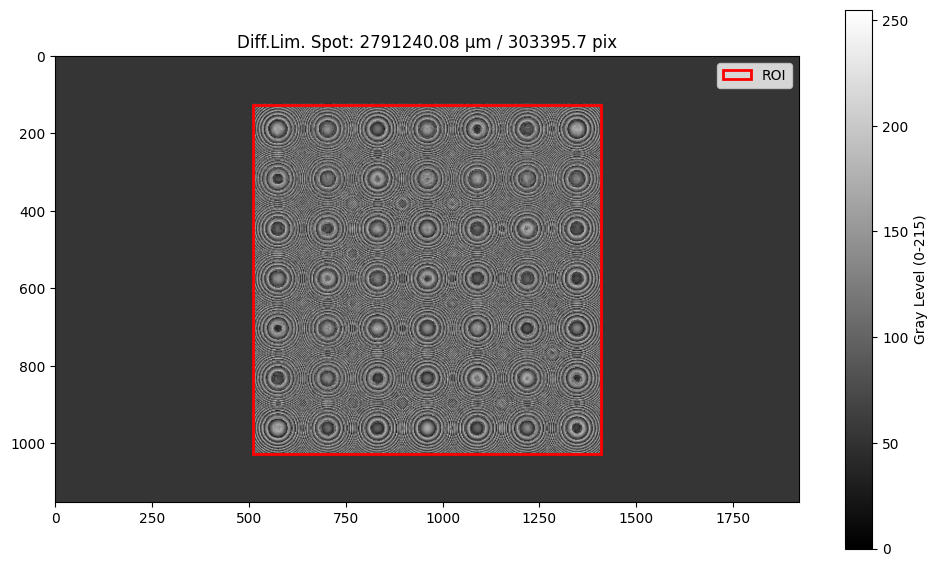

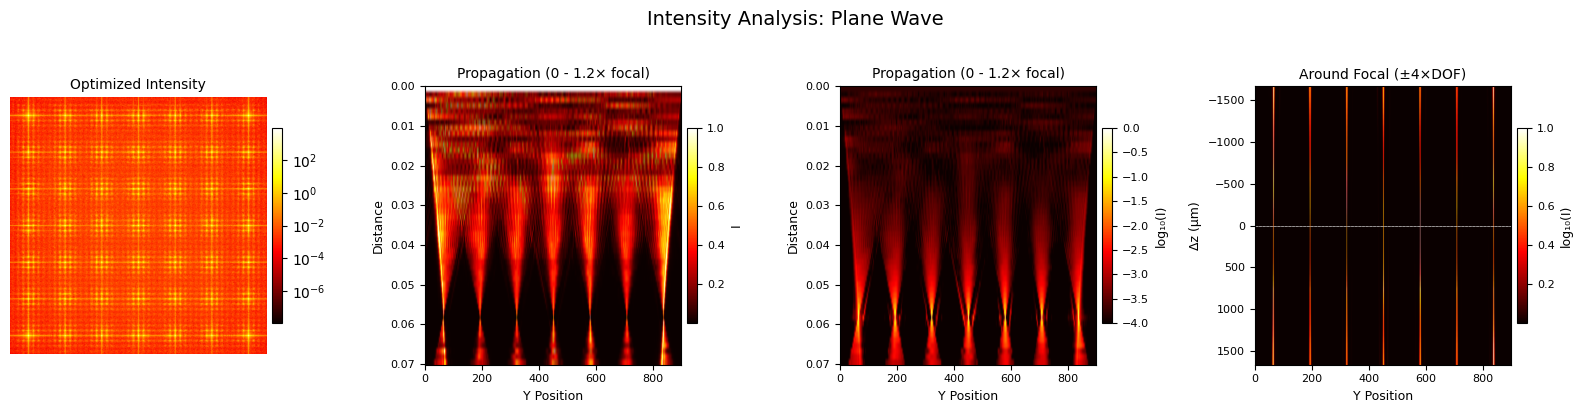

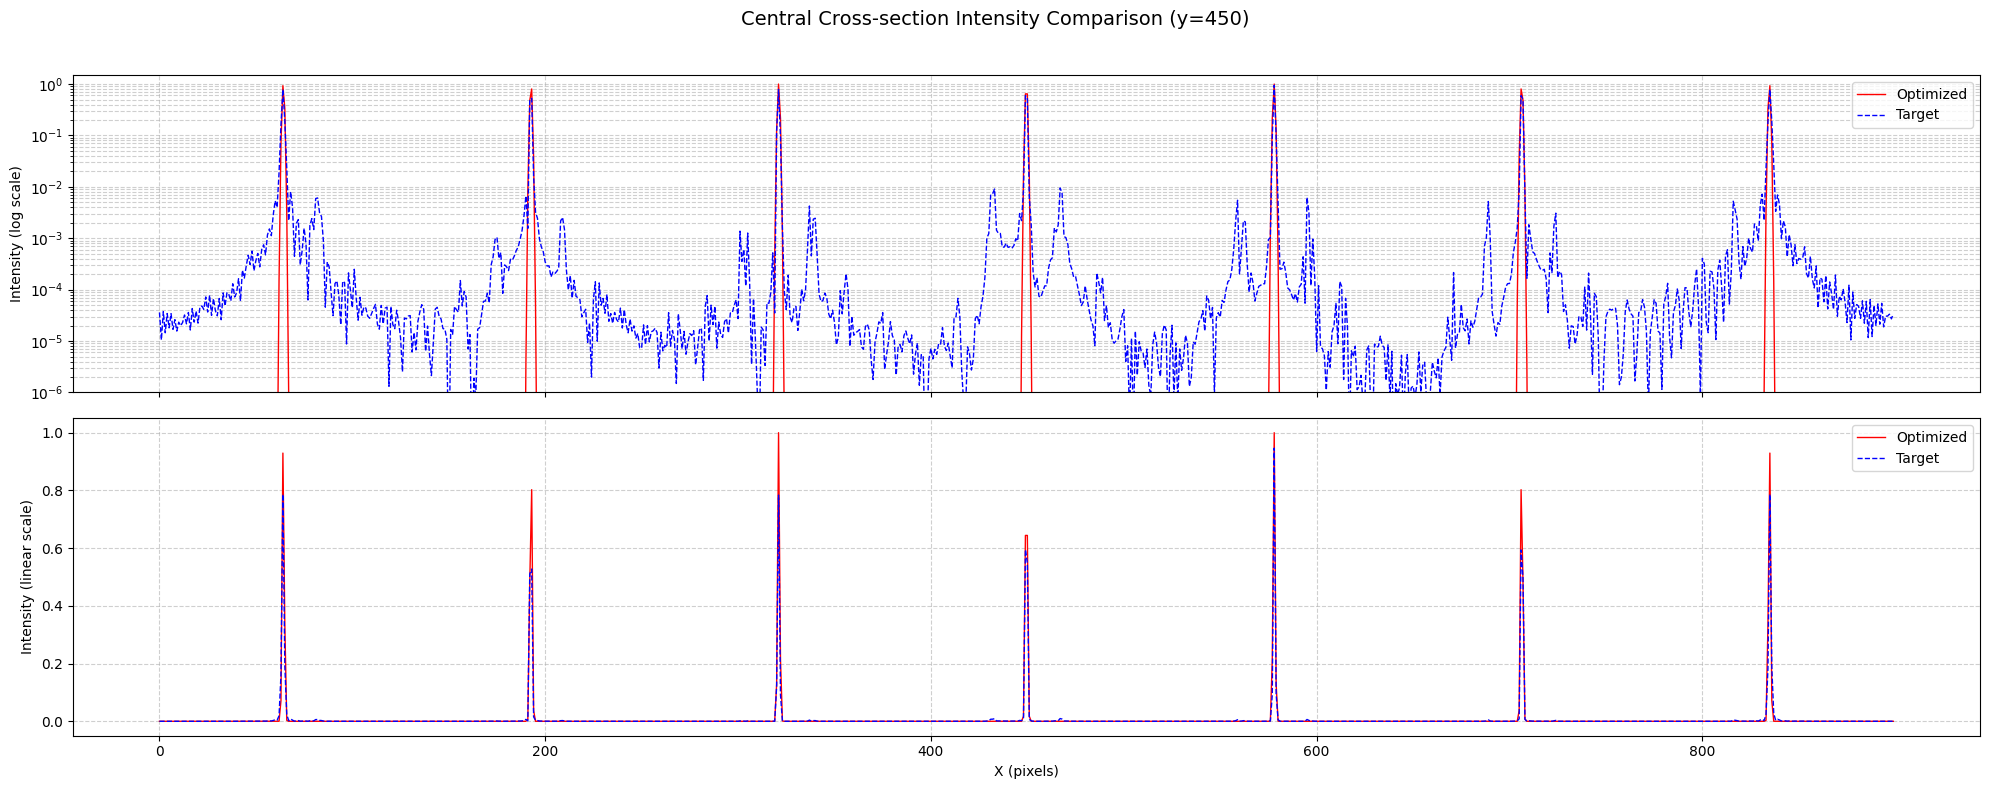

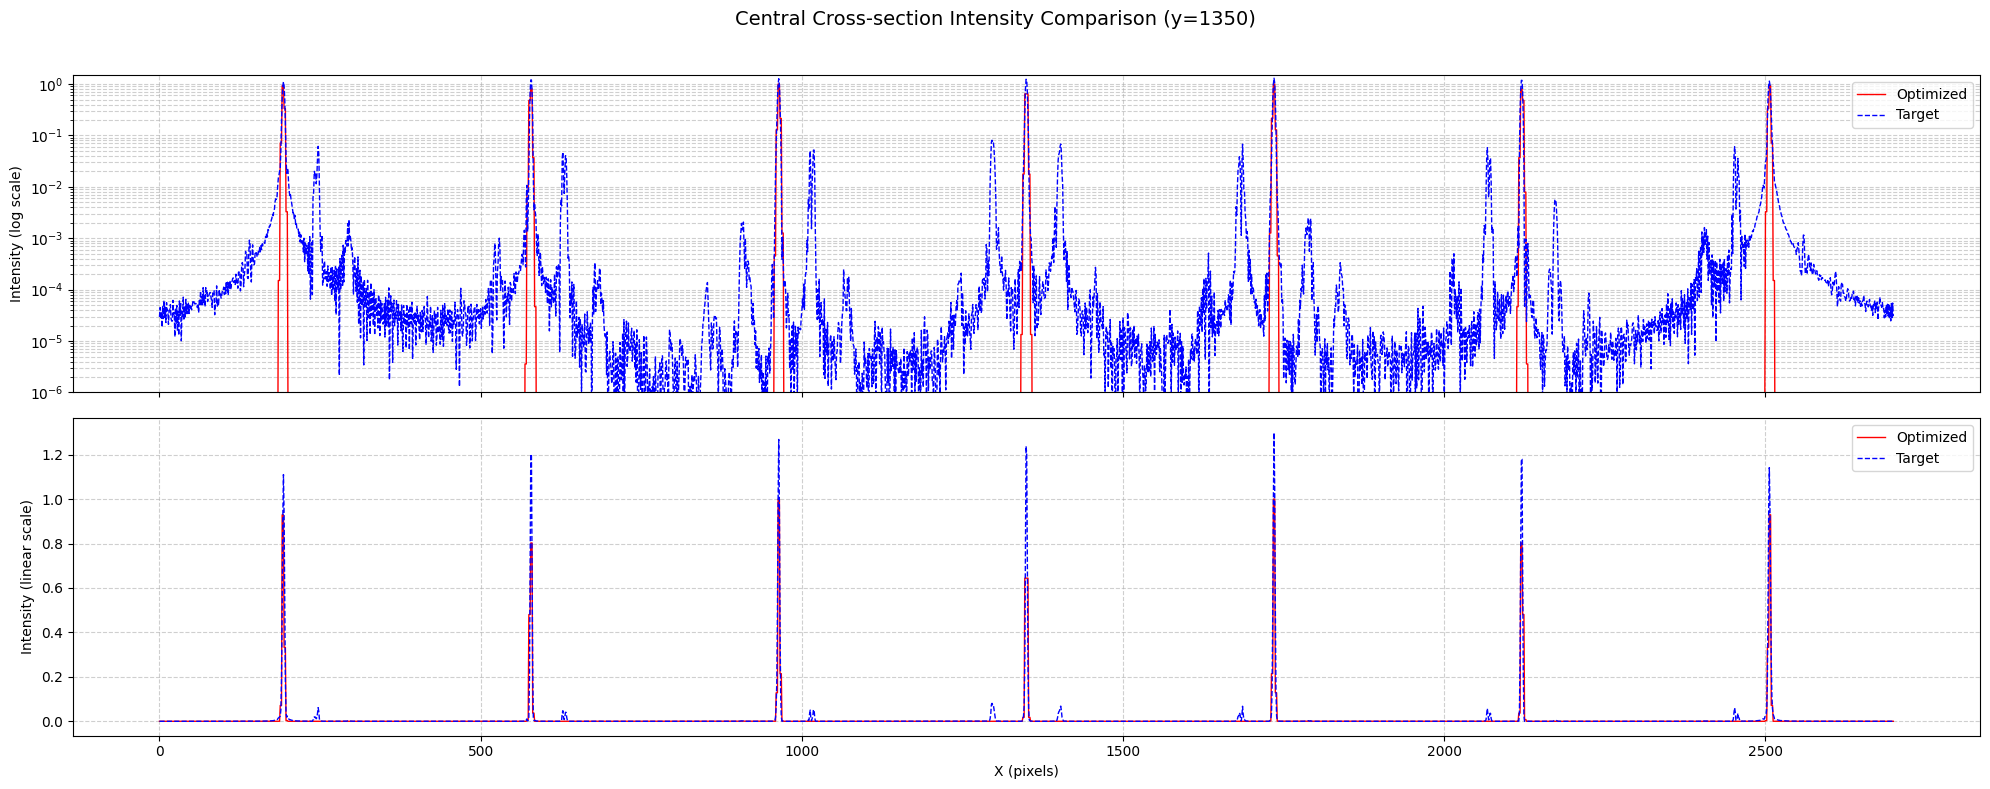

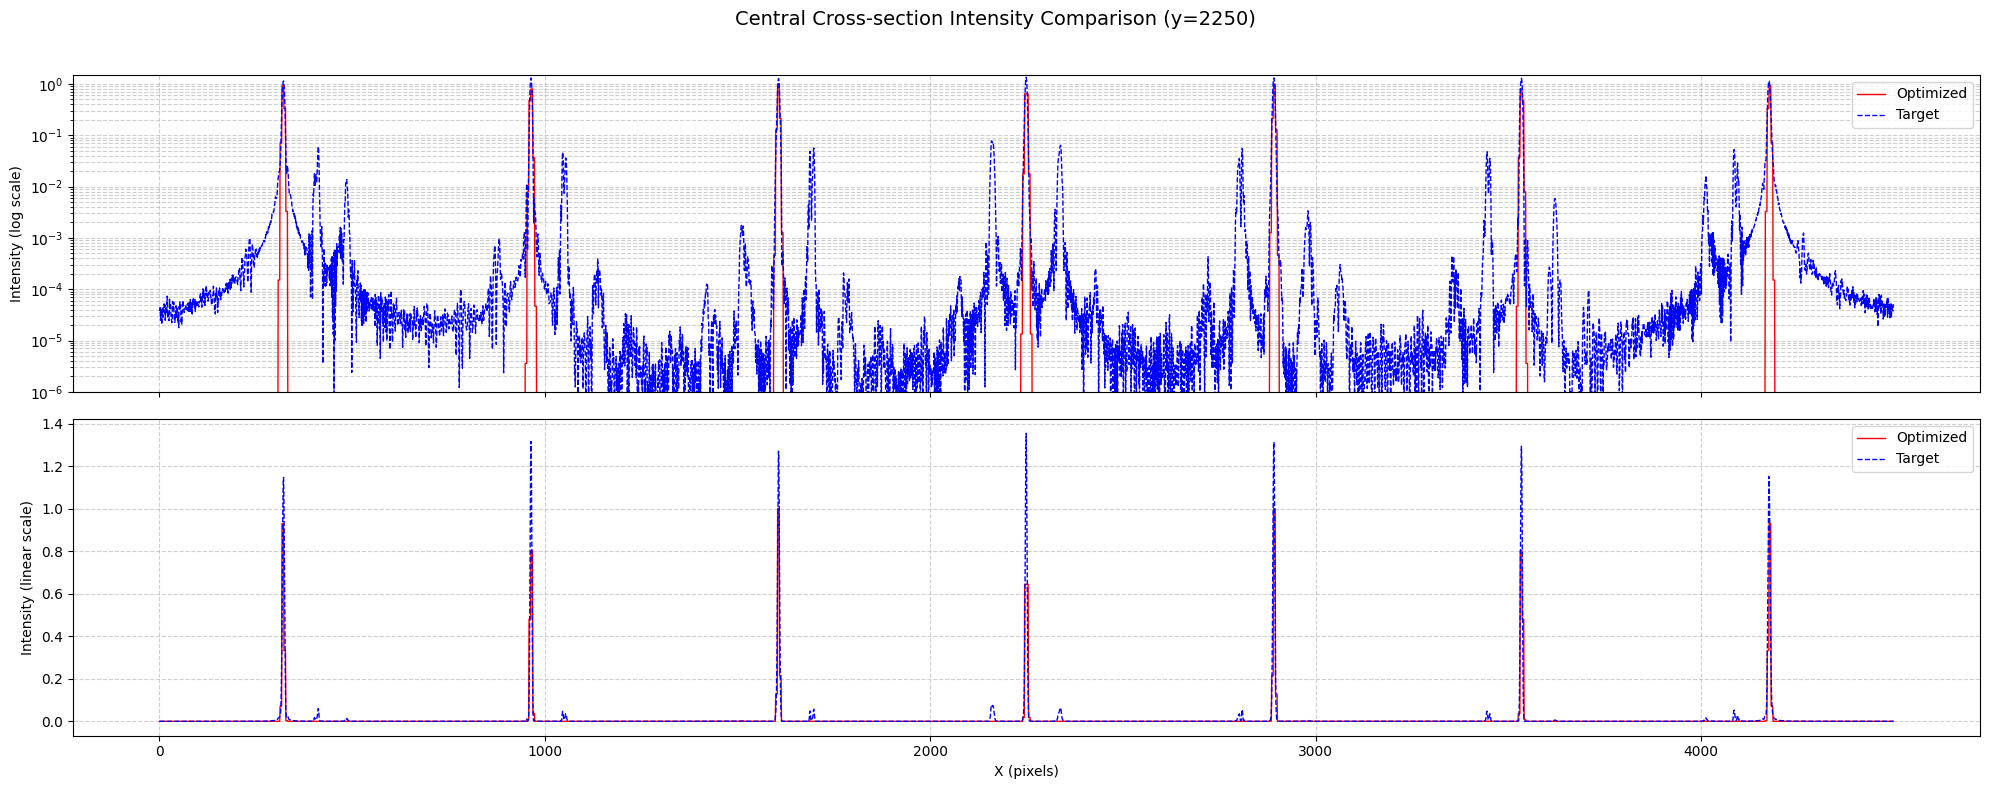

Encircled energy radius used for calculation: 1.40 pixels


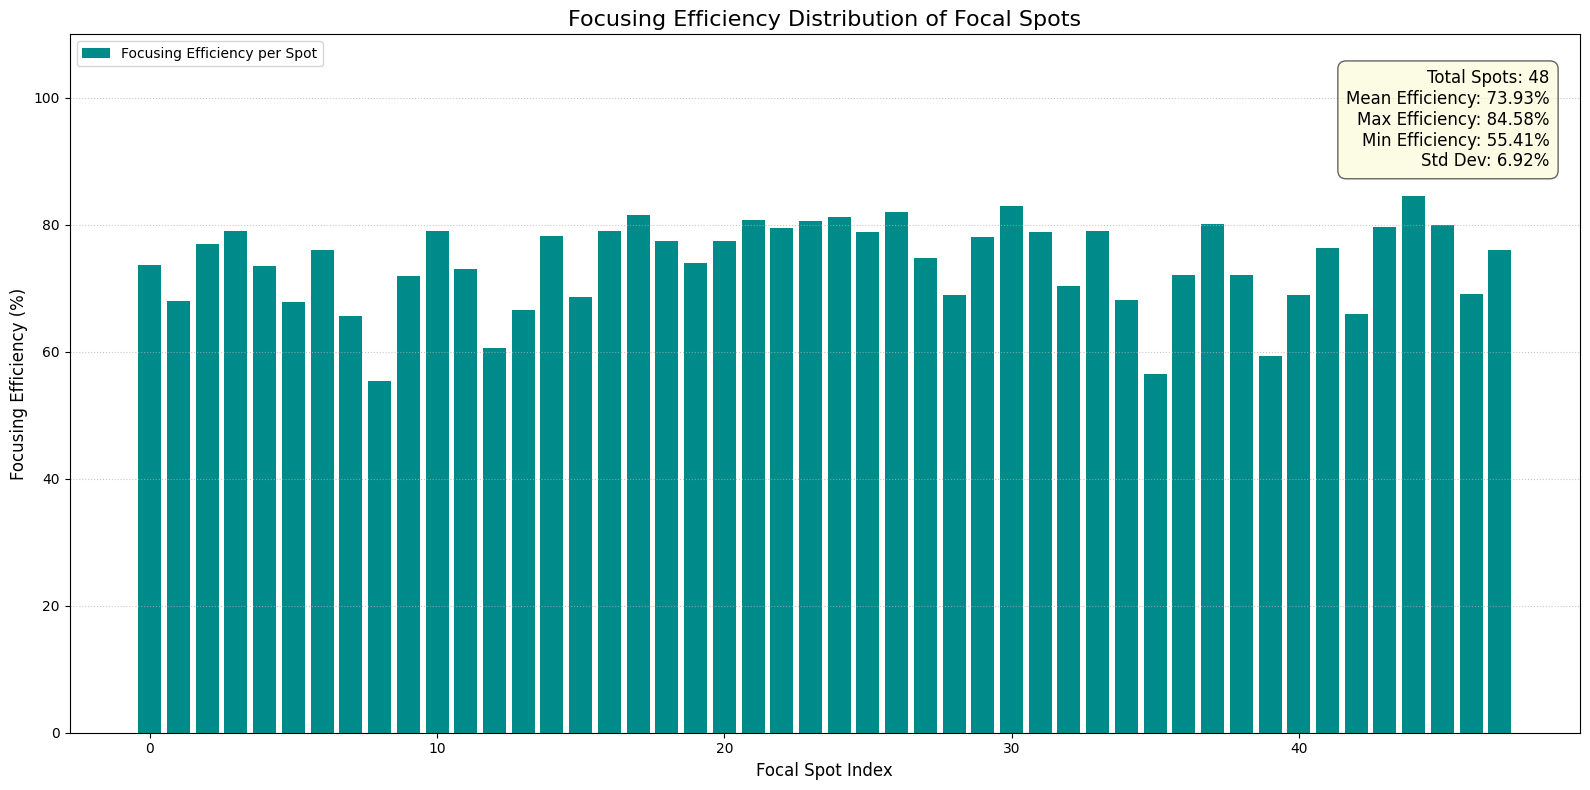

Encircled energy radius used for calculation: 4.19 pixels


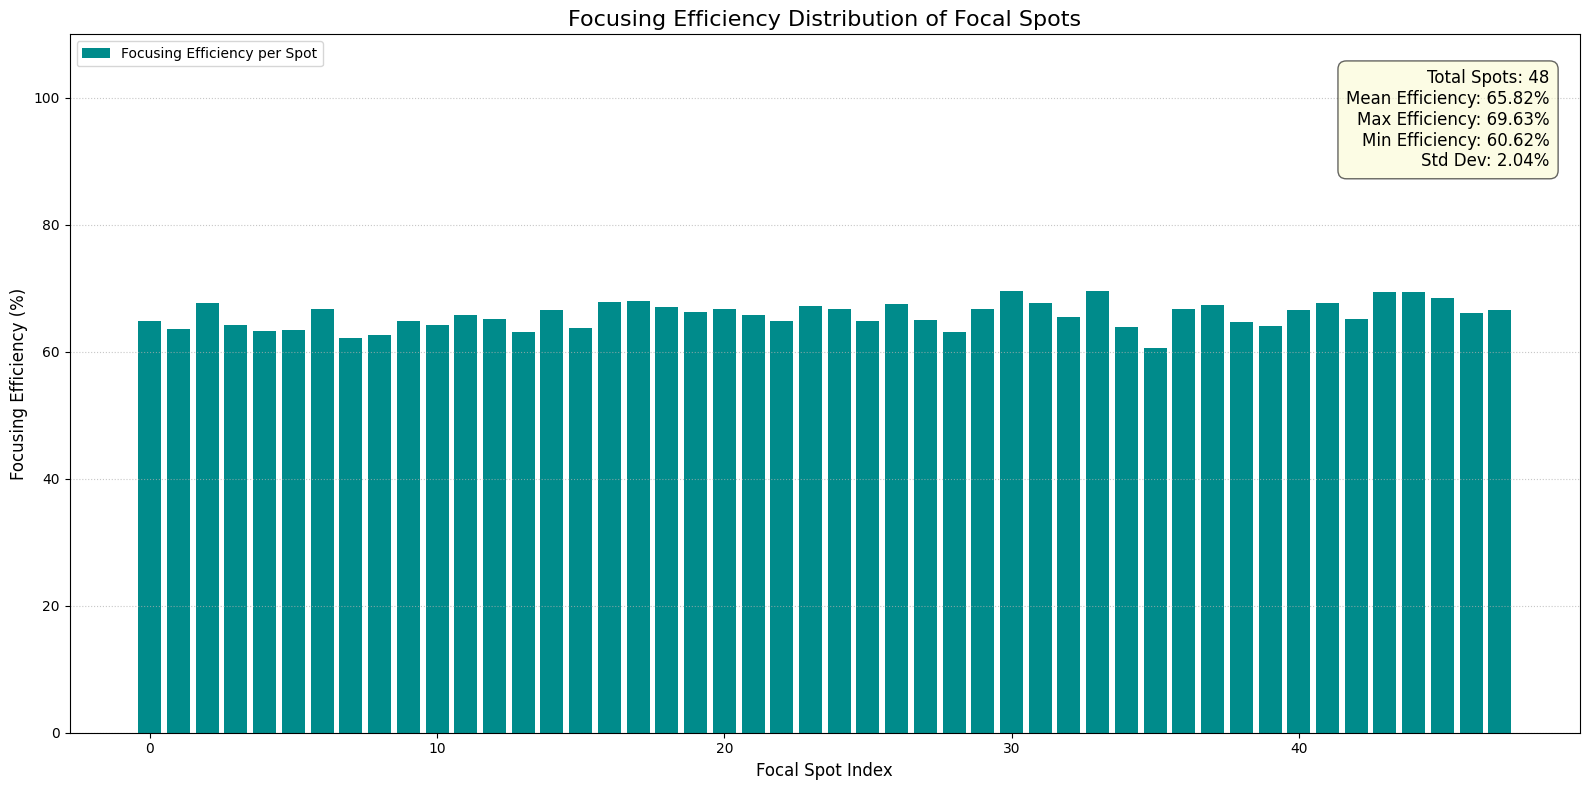

Encircled energy radius used for calculation: 6.98 pixels


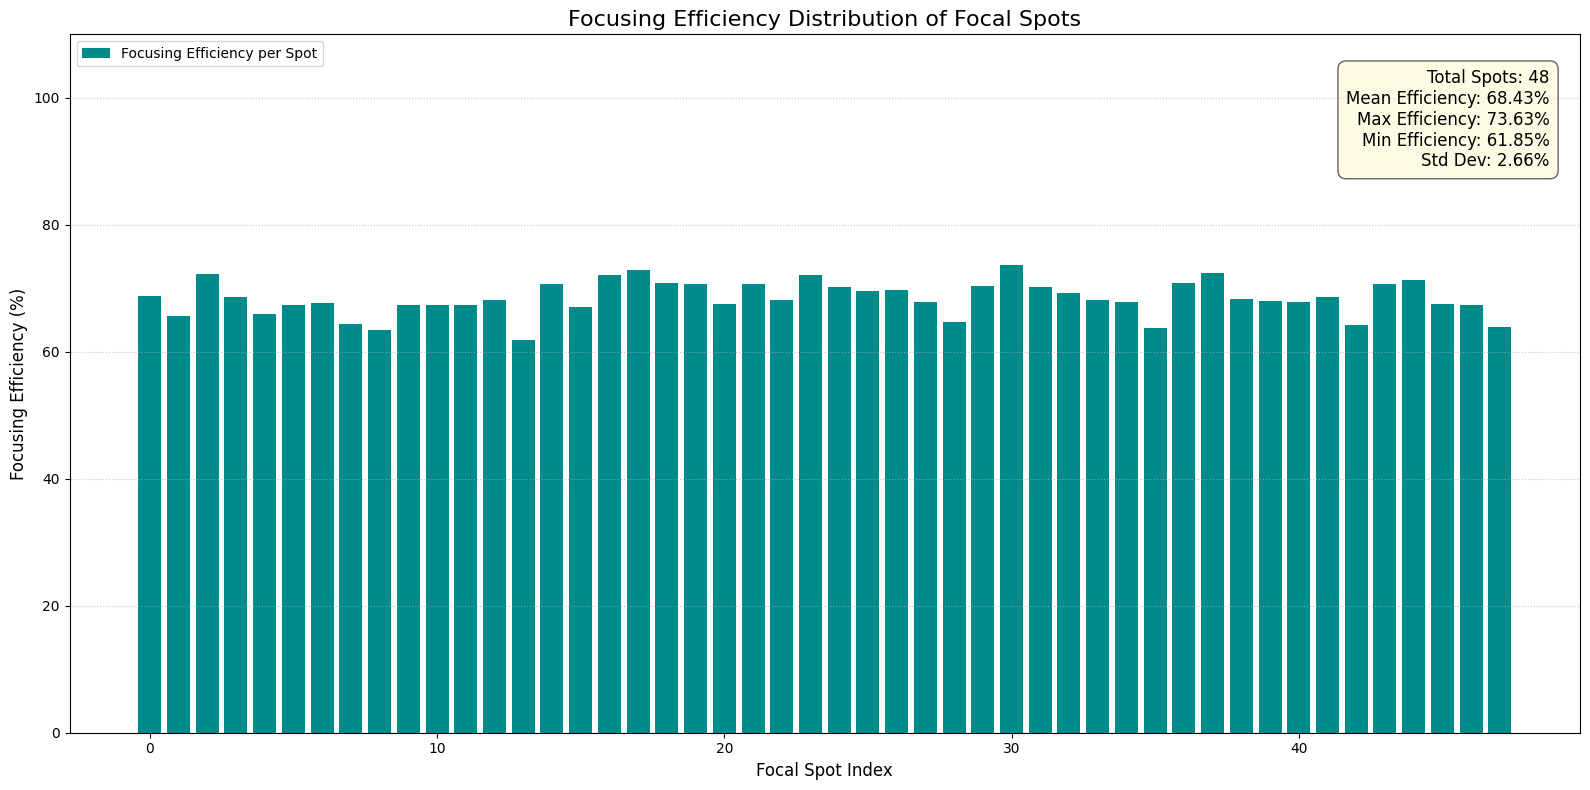

In [11]:
from visualization import plot_phase,plot_2d_comparisons, plot_cross_sections, plot_energy_distribution
# 可视化
plot_phase(Optimizer)
plot_2d_comparisons(Optimizer)
plot_cross_sections(Optimizer,upsampling=1.0)
plot_cross_sections(Optimizer,upsampling=3)
plot_cross_sections(Optimizer,upsampling=5)

plot_energy_distribution(Optimizer,upsampling=1)
plot_energy_distribution(Optimizer,upsampling=3)
plot_energy_distribution(Optimizer,upsampling=5)
